# AAI614: Data Science & its Applications

*Notebook 5.6: Decision Trees, Random Forests, and Visualizing Model Performance*

<a href="https://colab.research.google.com/github/techseeko/AAI614_Haidar/blob/main/Week-5/Saoud-Notebook5.6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

*Source: This notebook contains excerpts from the [Python Data Science Handbook](http://shop.oreilly.com/product/0636920034919.do) by Jake VanderPlas*

In [15]:
import numpy as np
import matplotlib.pyplot as plt

## Part I: Creating a Decision Tree

Consider the following two-dimensional data, which has one of four class labels (see the following figure):

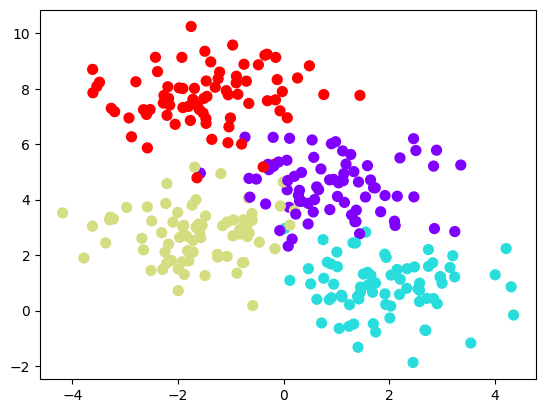

In [16]:
from sklearn.datasets import make_blobs

X, y = make_blobs(n_samples=300, centers=4,
                  random_state=0, cluster_std=1.0)
plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='rainbow');

A simple decision tree built on this data will iteratively split the data along one or the other axis according to some quantitative criterion, and at each level assign the label of the new region according to a majority vote of points within it.  The following figure presents a visualization of the first four levels of a decision tree classifier for this data.  Notice that after the first split, every point in the upper branch remains unchanged, so there is no need to further subdivide this branch.
Except for nodes that contain all of one color, at each level *every* region is again split along one of the two features.

This process of fitting a decision tree to the data can be done in Scikit-Learn with the ``DecisionTreeClassifier`` estimator:

In [17]:
from sklearn.tree import DecisionTreeClassifier
tree = DecisionTreeClassifier().fit(X, y)

Let's write a utility function to help us visualize the output of the classifier:

In [18]:
def visualize_classifier(model, X, y, ax=None, cmap='rainbow'):
    ax = ax or plt.gca()

    # Plot the training points
    ax.scatter(X[:, 0], X[:, 1], c=y, s=30, cmap=cmap,
               clim=(y.min(), y.max()), zorder=3)
    ax.axis('tight')
    ax.axis('off')
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()

    # fit the estimator
    model.fit(X, y)
    xx, yy = np.meshgrid(np.linspace(*xlim, num=200),
                         np.linspace(*ylim, num=200))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

    # Create a color plot with the results
    n_classes = len(np.unique(y))
    contours = ax.contourf(xx, yy, Z, alpha=0.3,
                           levels=np.arange(n_classes + 1) - 0.5,
                           cmap=cmap, zorder=1)

    ax.set(xlim=xlim, ylim=ylim)

Now we can examine what the decision tree classification looks like (see the following figure):

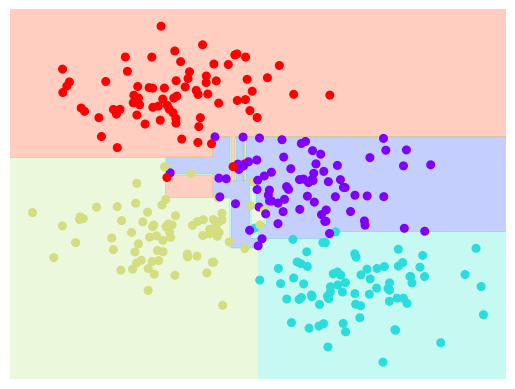

In [19]:
visualize_classifier(DecisionTreeClassifier(), X, y)

### Decision Trees and Overfitting

Such overfitting turns out to be a general property of decision trees: it is very easy to go too deep in the tree, and thus to fit details of the particular data rather than the overall properties of the distributions it is drawn from.
Another way to see this overfitting is to look at models trained on different subsets of the data—for example, in this figure we train two different trees, each on half of the original data.

It is clear that in some places the two trees produce consistent results (e.g., in the four corners), while in other places the two trees give very different classifications (e.g., in the regions between any two clusters).
The key observation is that the inconsistencies tend to happen where the classification is less certain, and thus by using information from *both* of these trees, we might come up with a better result!

#  Part II: Working with Random Forests

This notion—that multiple overfitting estimators can be combined to reduce the effect of this overfitting—is what underlies an ensemble method called *bagging*.
Bagging makes use of an ensemble (a grab bag, perhaps) of parallel estimators, each of which overfits the data, and averages the results to find a better classification.
An ensemble of randomized decision trees is known as a *random forest*.

This type of bagging classification can be done manually using Scikit-Learn's `BaggingClassifier` meta-estimator, as shown here (see the following figure):

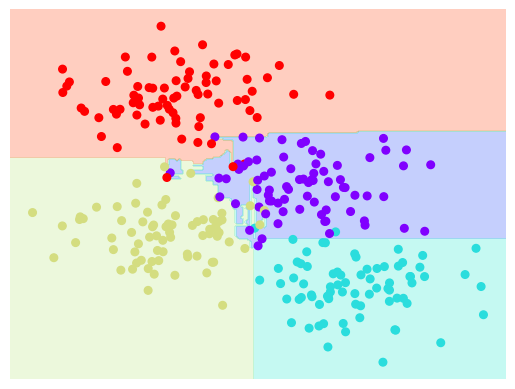

In [20]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier

tree = DecisionTreeClassifier()
bag = BaggingClassifier(tree, n_estimators=100, max_samples=0.8,
                        random_state=1)

bag.fit(X, y)
visualize_classifier(bag, X, y)

In this example, we have randomized the data by fitting each estimator with a random subset of 80% of the training points.
In practice, decision trees are more effectively randomized by injecting some stochasticity in how the splits are chosen: this way all the data contributes to the fit each time, but the results of the fit still have the desired randomness.
For example, when determining which feature to split on, the randomized tree might select from among the top several features.
You can read more technical details about these randomization strategies in the [Scikit-Learn documentation](http://scikit-learn.org/stable/modules/ensemble.html#forest) and references within.

In Scikit-Learn, such an optimized ensemble of randomized decision trees is implemented in the `RandomForestClassifier` estimator, which takes care of all the randomization automatically.
All you need to do is select a number of estimators, and it will very quickly—in parallel, if desired—fit the ensemble of trees (see the following figure):

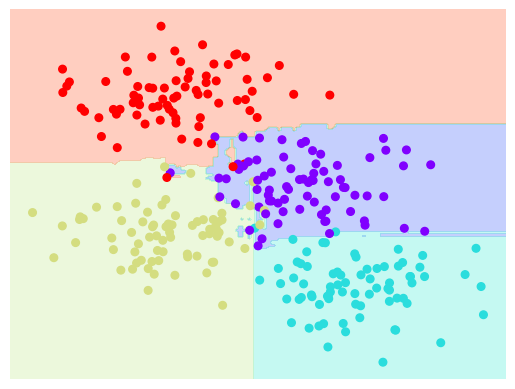

In [21]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=100, random_state=0)
visualize_classifier(model, X, y);

We see that by averaging over 100 randomly perturbed models, we end up with an overall model that is much closer to our intuition about how the parameter space should be split.

## Random Forest Regression

In the previous section we considered random forests within the context of classification.
Random forests can also be made to work in the case of regression (that is, with continuous rather than categorical variables). The estimator to use for this is the `RandomForestRegressor`, and the syntax is very similar to what we saw earlier.

Consider the following data, drawn from the combination of a fast and slow oscillation (see the following figure):

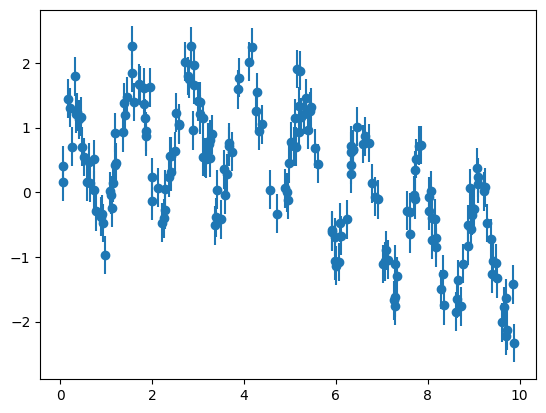

In [22]:
rng = np.random.RandomState(42)
x = 10 * rng.rand(200)

def model(x, sigma=0.3):
    fast_oscillation = np.sin(5 * x)
    slow_oscillation = np.sin(0.5 * x)
    noise = sigma * rng.randn(len(x))

    return slow_oscillation + fast_oscillation + noise

y = model(x)
plt.errorbar(x, y, 0.3, fmt='o');

Using the random forest regressor, we can find the best-fit curve as follows (see the following figure):

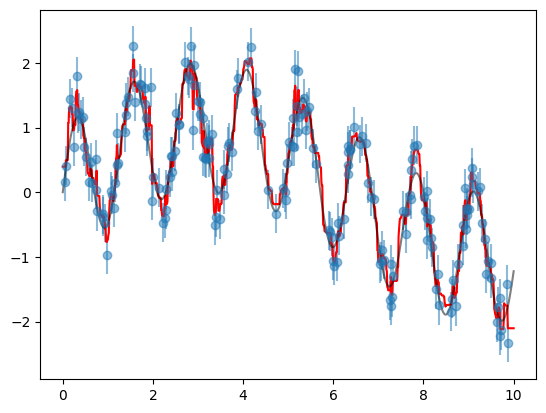

In [23]:
from sklearn.ensemble import RandomForestRegressor
forest = RandomForestRegressor(200)
forest.fit(x[:, None], y)

xfit = np.linspace(0, 10, 1000)
yfit = forest.predict(xfit[:, None])
ytrue = model(xfit, sigma=0)

plt.errorbar(x, y, 0.3, fmt='o', alpha=0.5)
plt.plot(xfit, yfit, '-r');
plt.plot(xfit, ytrue, '-k', alpha=0.5);

Here the true model is shown in the smooth gray curve, while the random forest model is shown by the jagged red curve.
The nonparametric random forest model is flexible enough to fit the multiperiod data, without us needing to specifying a multi-period model!

## Part III: Random Forest for Classifying Digits

In Chapter 38 we worked through an example using the digits dataset included with Scikit-Learn.
Let's use that again here to see how the random forest classifier can be applied in this context:

In [24]:
from sklearn.datasets import load_digits
digits = load_digits()
digits.keys()

dict_keys(['data', 'target', 'frame', 'feature_names', 'target_names', 'images', 'DESCR'])

To remind us what we're looking at, we'll visualize the first few data points (see the following figure):

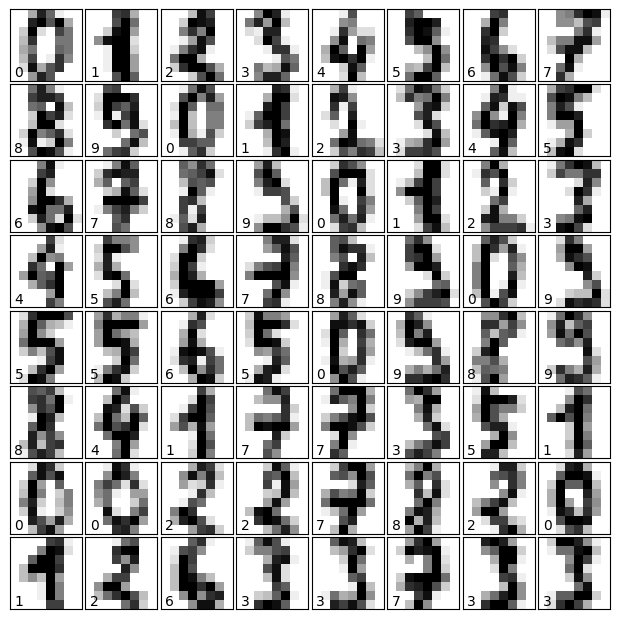

In [25]:
# set up the figure
fig = plt.figure(figsize=(6, 6))  # figure size in inches
fig.subplots_adjust(left=0, right=1, bottom=0, top=1, hspace=0.05, wspace=0.05)

# plot the digits: each image is 8x8 pixels
for i in range(64):
    ax = fig.add_subplot(8, 8, i + 1, xticks=[], yticks=[])
    ax.imshow(digits.images[i], cmap=plt.cm.binary, interpolation='nearest')

    # label the image with the target value
    ax.text(0, 7, str(digits.target[i]))

We can classify the digits using a random forest as follows:

In [26]:
from sklearn.model_selection import train_test_split

Xtrain, Xtest, ytrain, ytest = train_test_split(digits.data, digits.target,
                                                random_state=0)
model = RandomForestClassifier(n_estimators=1000)
model.fit(Xtrain, ytrain)
ypred = model.predict(Xtest)

Let's look at the classification report for this classifier:

In [27]:
from sklearn import metrics
print(metrics.classification_report(ypred, ytest))

              precision    recall  f1-score   support

           0       1.00      0.97      0.99        38
           1       0.98      0.98      0.98        43
           2       0.95      1.00      0.98        42
           3       0.98      0.96      0.97        46
           4       0.97      1.00      0.99        37
           5       0.98      0.96      0.97        49
           6       1.00      1.00      1.00        52
           7       1.00      0.96      0.98        50
           8       0.94      0.98      0.96        46
           9       0.98      0.98      0.98        47

    accuracy                           0.98       450
   macro avg       0.98      0.98      0.98       450
weighted avg       0.98      0.98      0.98       450



And for good measure, plot the confusion matrix (see the following figure):

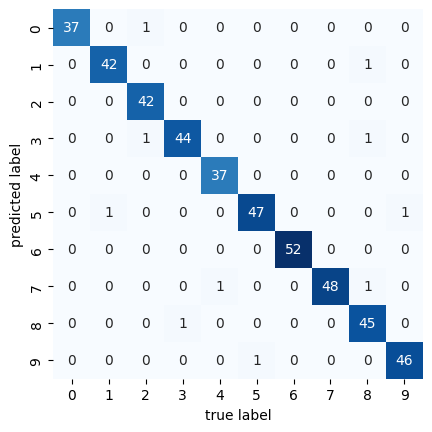

In [28]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
mat = confusion_matrix(ytest, ypred)
sns.heatmap(mat.T, square=True, annot=True, fmt='d',
            cbar=False, cmap='Blues')
plt.xlabel('true label')
plt.ylabel('predicted label');

# Part IV: Experimenting with Classifiers and Regressors

Now let's experiment with the models above to understand *how* and *why* they work. We'll vary key hyperparameters and observe the effects on decision boundaries, accuracy, and regression quality.

## Experiment 1: How does `max_depth` control Decision Tree overfitting?

A Decision Tree with unlimited depth memorizes every training point (overfitting). By limiting `max_depth`, we trade training accuracy for better generalization. Below we visualize decision boundaries at depths 1, 3, 5, and unlimited.

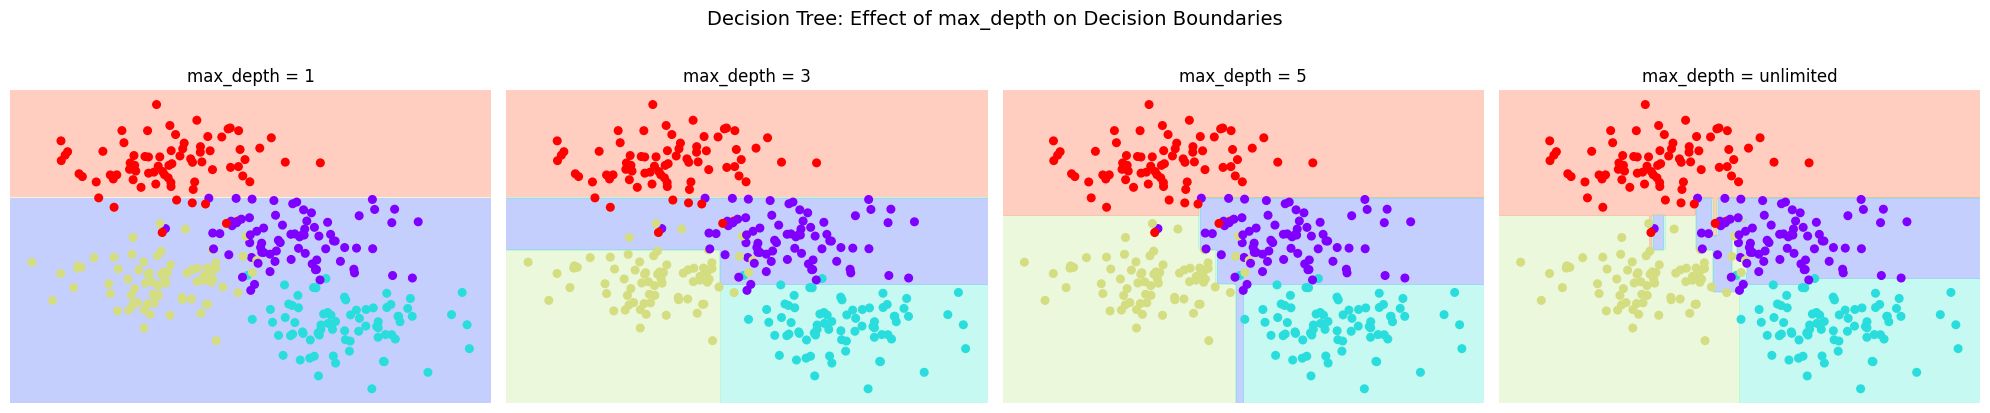

In [29]:
X, y = make_blobs(n_samples=300, centers=4, random_state=0, cluster_std=1.0)

fig, axes = plt.subplots(1, 4, figsize=(20, 4))
depths = [1, 3, 5, None]

for ax, depth in zip(axes, depths):
    label = "unlimited" if depth is None else str(depth)
    dt = DecisionTreeClassifier(max_depth=depth, random_state=0)
    visualize_classifier(dt, X, y, ax=ax)
    ax.set_title(f"max_depth = {label}")

plt.suptitle("Decision Tree: Effect of max_depth on Decision Boundaries", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

## Experiment 2: How does `n_estimators` affect Random Forest?

A Random Forest averages many trees. With very few trees the boundaries are noisy; as we add more, the decision surface smooths out. Here we compare 1, 5, 20, and 200 trees.

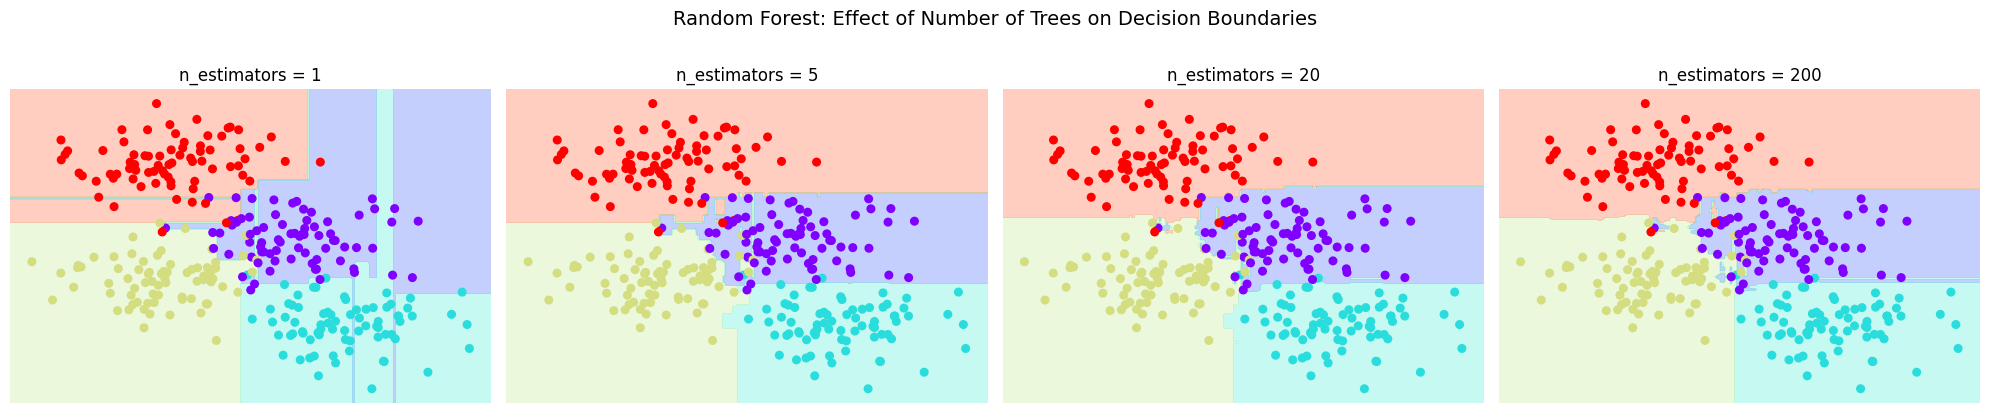

In [30]:
X, y = make_blobs(n_samples=300, centers=4, random_state=0, cluster_std=1.0)

fig, axes = plt.subplots(1, 4, figsize=(20, 4))
n_trees = [1, 5, 20, 200]

for ax, n in zip(axes, n_trees):
    rf = RandomForestClassifier(n_estimators=n, random_state=0)
    visualize_classifier(rf, X, y, ax=ax)
    ax.set_title(f"n_estimators = {n}")

plt.suptitle("Random Forest: Effect of Number of Trees on Decision Boundaries", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

## Experiment 3: How does `max_depth` affect Random Forest Regression?

In Part II we fit a Random Forest Regressor with default (unlimited) depth. Shallow trees under-fit the oscillation pattern, while very deep trees can chase noise. Below we sweep `max_depth` over 2, 5, 10, and unlimited to see the bias–variance trade-off on the regression curve.

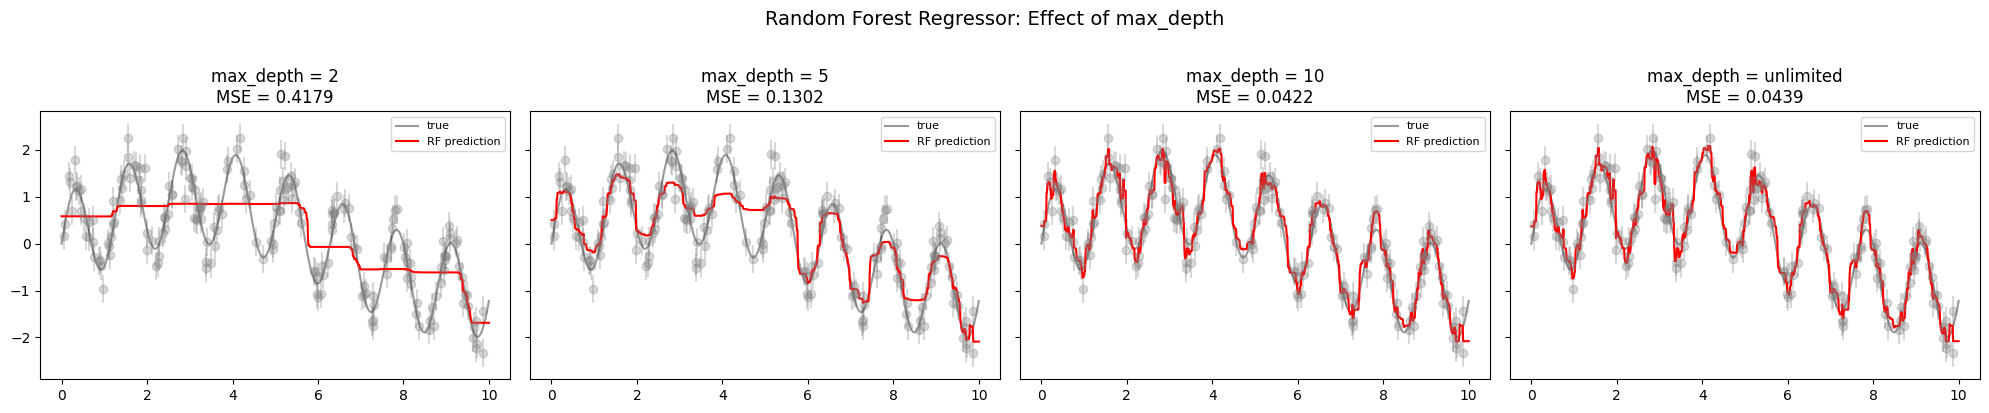

In [31]:
from sklearn.metrics import mean_squared_error

rng_exp = np.random.RandomState(42)
x_exp = 10 * rng_exp.rand(200)

def true_model(x, sigma=0.3):
    noise = sigma * rng_exp.randn(len(x))
    return np.sin(0.5 * x) + np.sin(5 * x) + noise

y_exp = true_model(x_exp)
xfit = np.linspace(0, 10, 1000)

rng_true = np.random.RandomState(42)
_ = rng_true.rand(200)
_ = rng_true.randn(200)
ytrue = np.sin(0.5 * xfit) + np.sin(5 * xfit)

fig, axes = plt.subplots(1, 4, figsize=(20, 4), sharey=True)
depths = [2, 5, 10, None]

for ax, depth in zip(axes, depths):
    label = "unlimited" if depth is None else str(depth)
    rf_reg = RandomForestRegressor(n_estimators=200, max_depth=depth, random_state=0)
    rf_reg.fit(x_exp[:, None], y_exp)
    yfit = rf_reg.predict(xfit[:, None])
    mse = mean_squared_error(ytrue, yfit)

    ax.errorbar(x_exp, y_exp, 0.3, fmt='o', alpha=0.3, color='gray')
    ax.plot(xfit, ytrue, '-k', alpha=0.4, label='true')
    ax.plot(xfit, yfit, '-r', label='RF prediction')
    ax.set_title(f"max_depth = {label}\nMSE = {mse:.4f}")
    ax.legend(loc='upper right', fontsize=8)

plt.suptitle("Random Forest Regressor: Effect of max_depth", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

## Experiment 4: Digits — Cross-Validation Accuracy and Feature Importance

A single train/test split can be lucky or unlucky. 5-fold cross-validation gives a more robust accuracy estimate. We also extract `feature_importances_` from the forest — each importance value maps to one of the 64 pixels (8 x 8 image), revealing which pixel positions the model relies on most for classification.

5-Fold Cross-Validation Accuracy
-----------------------------------
  Fold 1: 0.9361
  Fold 2: 0.9056
  Fold 3: 0.9554
  Fold 4: 0.9666
  Fold 5: 0.9248
  Mean:   0.9377 +/- 0.0217


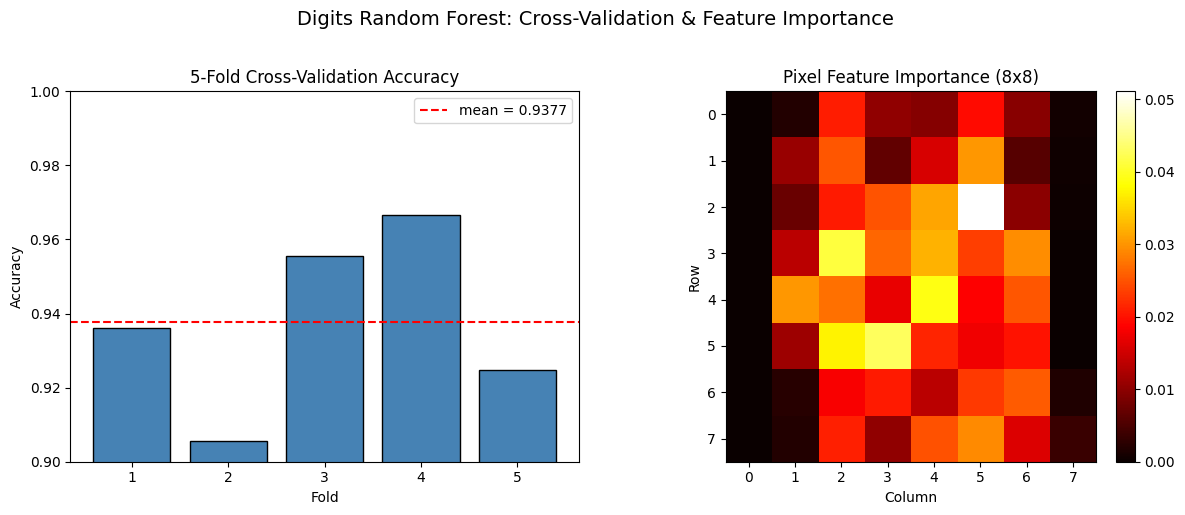

In [32]:
from sklearn.model_selection import cross_val_score

digits = load_digits()
rf_digits = RandomForestClassifier(n_estimators=500, random_state=0)

cv_scores = cross_val_score(rf_digits, digits.data, digits.target, cv=5, scoring='accuracy')

print("5-Fold Cross-Validation Accuracy")
print("-" * 35)
for i, score in enumerate(cv_scores, 1):
    print(f"  Fold {i}: {score:.4f}")
print(f"  Mean:   {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}")

rf_digits.fit(digits.data, digits.target)
importances = rf_digits.feature_importances_.reshape(8, 8)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(range(1, 6), cv_scores, color='steelblue', edgecolor='black')
axes[0].axhline(cv_scores.mean(), color='red', linestyle='--', label=f'mean = {cv_scores.mean():.4f}')
axes[0].set_xlabel('Fold')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('5-Fold Cross-Validation Accuracy')
axes[0].set_ylim(0.9, 1.0)
axes[0].legend()

im = axes[1].imshow(importances, cmap='hot', interpolation='nearest')
axes[1].set_title('Pixel Feature Importance (8x8)')
axes[1].set_xlabel('Column')
axes[1].set_ylabel('Row')
plt.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)

plt.suptitle("Digits Random Forest: Cross-Validation & Feature Importance", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()